# Actividad 5

## Codigo para diagrama de bifurcación, $x$ vs $\gamma$ 

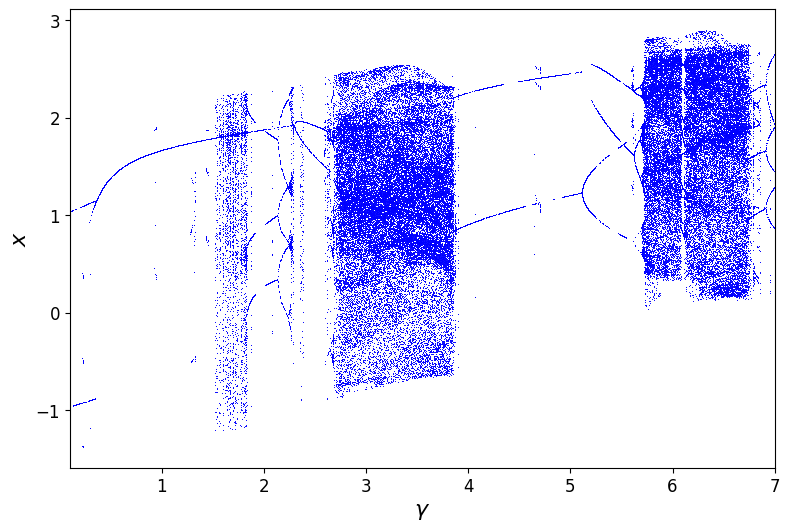

In [14]:
import numpy as np
from numpy import sin,cos,pi
import matplotlib.pyplot as plt

# system parameters
alpha=2
delta=0.1
beta=2
omega=1.2
T=2*pi/omega

#initial conditions
x0,v0= 1, 1

#Bifurcation parameter: gamma
g_min= 0.1
g_max= 7
dg=0.001
g_values= np.arange(g_min,g_max+dg,dg)
n_orbitas = len(g_values)

#initial state
x=np.full(n_orbitas,x0)
v=np.full(n_orbitas,v0)
y=np.concatenate([x,v])

# numerical method parameters
Trans=200
Nkeep=35
steps_per_T=200
dt=T/steps_per_T

#Dynamics
def dyn(t,y):
    x=y[:n_orbitas]
    v=y[n_orbitas:]
    dx=v
    dv=-(delta)*v+alpha*x-(beta)*x**3+g_values*cos(omega*t)
    return np.concatenate([dx,dv])

#fourth-order Runge-Kutta method
def rk4(f,t,y,h):
    k1= h*f(t,y)
    k2= h*f(t+h/2,y+k1/2)
    k3= h*f(t+h/2,y+k2/2)
    k4= h*f(t+h,y+k3)
    return y+(k1+2*k2+2*k3+k4)/6

#stroboscopic storage
x_strobe=np.empty((Nkeep,n_orbitas))
v_strobe=np.empty((Nkeep,n_orbitas))
save_index=0

#integration
total_periods=Trans+Nkeep
total_steps=total_periods * steps_per_T
for step in range(total_steps):
    current_time=step*dt
    y=rk4(dyn,current_time,y,dt)
    completed_period=(step+1)//steps_per_T
    if(step+1) %steps_per_T==0:
        if completed_period >Trans:
            x_strobe[save_index]=y[:n_orbitas]
            v_strobe[save_index]=y[n_orbitas:]
            save_index+=1

# Bifurcation diagram y Figure format
fig,ax= plt.subplots(figsize=(8,6))
for i in range(n_orbitas):
    ax.scatter(np.full(Nkeep,g_values[i]),
               (x_strobe[:,i]),s=0.5,color="blue",linewidths=0,rasterized=True)
ax.set_xlabel(r"$\gamma$", fontsize=16)
ax.set_ylabel(r"$x$",fontsize=16)
ax.tick_params(axis="both",labelsize=12)
ax.set_xlim(g_min, g_max)
ax.set_box_aspect(0.65)
plt.tight_layout()
plt.savefig("Bifurcation_1.png",format="png",bbox_inches="tight",dpi=800)
plt.show()

## Codigo para diagrama de bifurcación, $\dot{x}$ vs $\gamma$

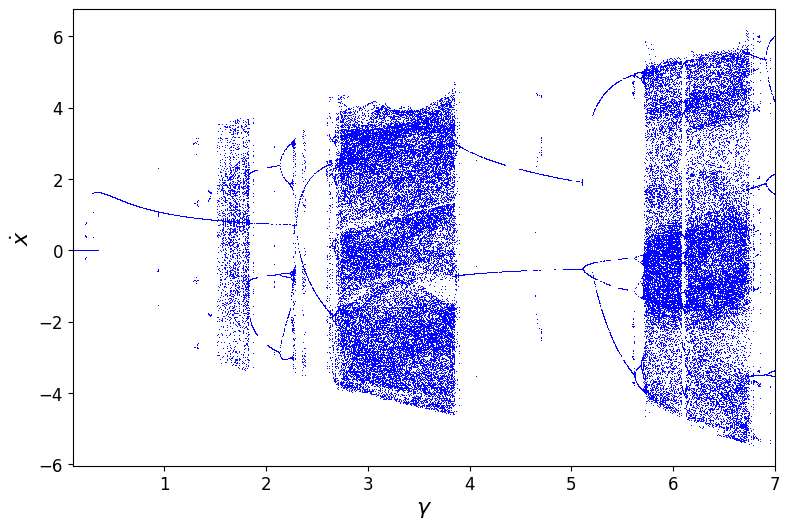

In [15]:
import numpy as np
from numpy import sin,cos,pi
import matplotlib.pyplot as plt

# system parameters
alpha=2
delta=0.1
beta=2
omega=1.2
T=2*pi/omega

#initial conditions
x0,v0= 1, 1

#Bifurcation parameter: gamma
g_min= 0.1
g_max= 7
dg=0.001
g_values= np.arange(g_min,g_max+dg,dg)
n_orbitas = len(g_values)

#initial state
x=np.full(n_orbitas,x0)
v=np.full(n_orbitas,v0)
y=np.concatenate([x,v])

# numerical method parameters
Trans=200
Nkeep=32
steps_per_T=200
dt=T/steps_per_T

#Dynamics
def dyn(t,y):
    x=y[:n_orbitas]
    v=y[n_orbitas:]
    dx=v
    dv=-(delta)*v+alpha*x-(beta)*x**3+g_values*cos(omega*t)
    return np.concatenate([dx,dv])

#fourth-order Runge-Kutta method
def rk4(f,t,y,h):
    k1= h*f(t,y)
    k2= h*f(t+h/2,y+k1/2)
    k3= h*f(t+h/2,y+k2/2)
    k4= h*f(t+h,y+k3)
    return y+(k1+2*k2+2*k3+k4)/6

#stroboscopic storage
x_strobe=np.empty((Nkeep,n_orbitas))
v_strobe=np.empty((Nkeep,n_orbitas))
save_index=0

#integration
total_periods=Trans+Nkeep
total_steps=total_periods * steps_per_T
for step in range(total_steps):
    current_time=step*dt
    y=rk4(dyn,current_time,y,dt)
    completed_period=(step+1)//steps_per_T
    if(step+1) %steps_per_T==0:
        if completed_period >Trans:
            x_strobe[save_index]=y[:n_orbitas]
            v_strobe[save_index]=y[n_orbitas:]
            save_index+=1

# Bifurcation diagram y Figure format
fig,ax= plt.subplots(figsize=(8,6))
for i in range(n_orbitas):
    ax.scatter(np.full(Nkeep,g_values[i]),
               (v_strobe[:,i]),s=0.5,color="blue",linewidths=0,rasterized=True)
ax.set_xlabel(r"$\gamma$", fontsize=16)
ax.set_ylabel(r"$\dot{x}$",fontsize=16)
ax.tick_params(axis="both",labelsize=12)
ax.set_xlim(g_min, g_max)
ax.set_box_aspect(0.65)
plt.tight_layout()
plt.savefig("Bifurcation_2.png",format="png",bbox_inches="tight",dpi=800)
plt.show()